# EDA comparativa: FakeRecogna Excel versus FakeRecogna extrativo

Este notebook mantém `FakeTrueBr` e `fakeWhatsApp` constantes para medir exclusivamente o efeito de substituir o FakeRecogna Excel pelo FakeRecogna extrativo. A primeira parte audita o extrativo isoladamente; a segunda compara os dois cenários consolidados.

Convenção comum: `label = 0` representa conteúdo falso e `label = 1` representa conteúdo verdadeiro. No CSV extrativo, o rótulo original é invertido durante a harmonização porque `Label = 1` representa falso e `Label = 0` representa verdadeiro.

## 1. Preparação reproduzível

As regras de carga, validação, limpeza, normalização e exportação ficam em `src/data/comparative_eda.py`. O notebook chama essas regras para evitar divergência entre análise visual e CSVs gerados.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').is_dir():
    raise RuntimeError('Execute o notebook na raiz do checa-ai-ml ou na pasta notebooks.')
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.comparative_eda import (
    build_scenarios, comparison_table, export_scenarios, load_sources,
    source_overlap, summarize,
)

sns.set_theme(style='whitegrid')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
print('Projeto:', PROJECT_ROOT)
print('Dados brutos:', RAW_DIR)

Projeto: /Users/aluno2/dev/checa-ai-ml
Dados brutos: /Users/aluno2/dev/checa-ai-ml/data/raw


In [2]:
sources, sanitation_audit = load_sources(RAW_DIR)
scenarios = build_scenarios(sources)
generated_paths = export_scenarios(scenarios, PROCESSED_DIR)

audit_table = pd.DataFrame.from_dict(sanitation_audit, orient='index')
audit_table.index.name = 'dataset'
display(audit_table)
print('Arquivos gerados:')
for path in generated_paths:
    print('-', path.relative_to(PROJECT_ROOT))

,input_rows,empty_rows,short_rows,valid_rows
dataset,,,,
recogna_excel,11902,0,20,11882
recogna_extrativo,52800,0,59,52741
fake_true_br,3582,0,0,3582
whatsapp,21289,0,0,21289


Arquivos gerados:
- data/processed/consolidado_excel.csv
- data/processed/consolidado_excel_deduplicado.csv
- data/processed/consolidado_extrativo.csv
- data/processed/consolidado_extrativo_deduplicado.csv
- data/processed/comparacao_consolidados.csv


## 2. EDA isolada do FakeRecogna extrativo

Esta seção verifica volume, classes, comprimento, duplicatas e possíveis assinaturas editoriais antes de misturar o extrativo às outras bases.

In [3]:
df_extrativo = sources['recogna_extrativo'].copy()
extrativo_summary = pd.DataFrame([summarize(df_extrativo, name='FakeRecogna_Extrativo')])
display(extrativo_summary.T.rename(columns={0: 'valor'}))
display(df_extrativo[['text', 'label', 'source', 'original_id', 'title', 'url']].head())

,valor
scenario,FakeRecogna_Extrativo
rows,52741
fake_rows,26370
real_rows,26371
fake_rate,0.499991
unique_texts,52603
duplicate_rows,138
label_conflicts,4
median_chars,576.0
median_words,94.0


,text,label,source,original_id,title,url
0,chico anysio disse “se é a pobreza que vota na...,0,FakeRecogna_Extrativo,31105,Chico Anysio disse “Se é a pobreza que vota na...,https://www.boatos.org/entretenimento/chico-an...
1,o áudio compartilhado através de grupos do wha...,0,FakeRecogna_Extrativo,40303,O Padre Marcelo Rossi gravou áudio pedindo vot...,http://www.e-farsas.com/o-padre-marcelo-rossi-...
2,gestores dos 52 municípios de rondônia se reun...,1,FakeRecogna_Extrativo,6014,Rondônia recebe a Oficina Previne Brasil nesta...,https://www.gov.br/saude/pt-br/assuntos/notici...
3,“durma-se com um barulho desse: viúva do che g...,0,FakeRecogna_Extrativo,50488,\n Viúva de Che Guevara não poderia receber a...,https://checamos.afp.com//doc.afp.com.32H6946
4,um vídeo que circula nas redes sociais mostre ...,0,FakeRecogna_Extrativo,28833,\nVídeo não mostra urna adulterada dentro de c...,https://www.aosfatos.org/noticias/video-nao-mo...


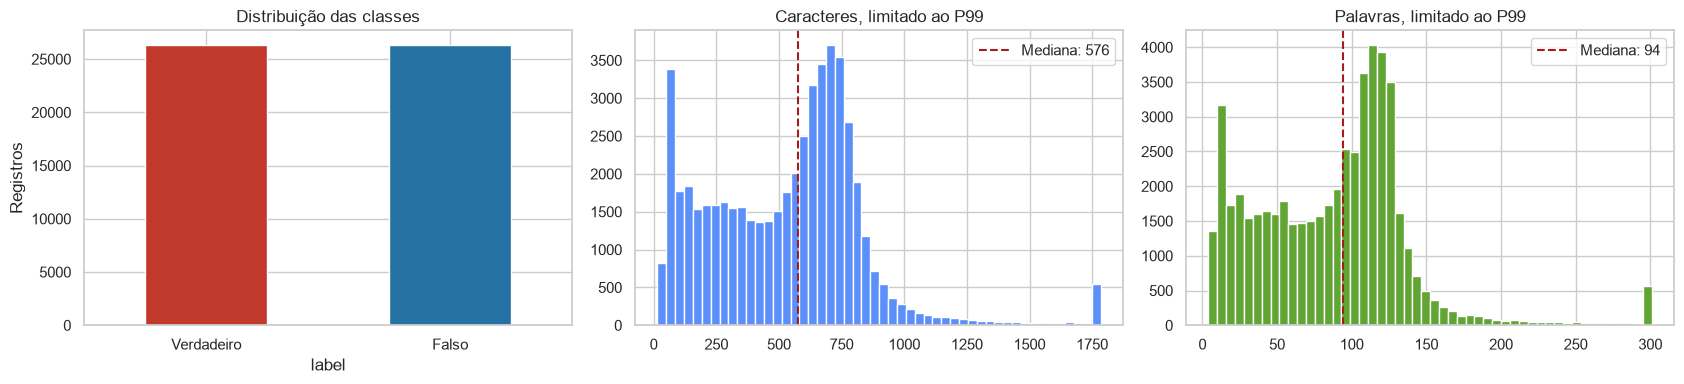

In [4]:
class_counts = df_extrativo['label'].map({0: 'Falso', 1: 'Verdadeiro'}).value_counts()
lengths = df_extrativo['text'].str.len()
words = df_extrativo['text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
class_counts.plot.bar(ax=axes[0], color=['#c0392b', '#2471a3'])
axes[0].set_title('Distribuição das classes')
axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=0)
axes[1].hist(lengths.clip(upper=lengths.quantile(.99)), bins=50, color='#5b8ff9')
axes[1].axvline(lengths.median(), color='#a61b1b', linestyle='--', label=f'Mediana: {lengths.median():.0f}')
axes[1].set_title('Caracteres, limitado ao P99')
axes[1].legend()
axes[2].hist(words.clip(upper=words.quantile(.99)), bins=50, color='#61a534')
axes[2].axvline(words.median(), color='#a61b1b', linestyle='--', label=f'Mediana: {words.median():.0f}')
axes[2].set_title('Palavras, limitado ao P99')
axes[2].legend()
plt.tight_layout()
plt.show()

In [5]:
def style_metrics(frame):
    text = frame['text'].astype(str)
    chars = text.str.len().clip(lower=1)
    letters = text.str.count(r'[A-Za-zÀ-ÖØ-öø-ÿ]').clip(lower=1)
    upper = text.str.count(r'[A-ZÀ-ÖØ-Þ]')
    return pd.DataFrame({
        'exclamacoes_por_1000_chars': text.str.count('!') / chars * 1000,
        'interrogacoes_por_1000_chars': text.str.count(r'\?') / chars * 1000,
        'proporcao_maiusculas': upper / letters,
    })

style_extrativo = style_metrics(df_extrativo).assign(label=df_extrativo['label'])
style_by_class = style_extrativo.groupby('label').mean().rename(index={0: 'Falso', 1: 'Verdadeiro'})
display(style_by_class)

,exclamacoes_por_1000_chars,interrogacoes_por_1000_chars,proporcao_maiusculas
label,,,
Falso,1.460229,0.754345,0.0
Verdadeiro,0.033132,0.078933,0.0


### Tokenização BERTimbau

A célula seguinte usa o tokenizer oficial. Se o modelo ainda não estiver no cache local, a primeira execução precisa de acesso à internet. Uma falha é exibida explicitamente; palavras ou caracteres não são apresentados como se fossem tokens BERT.

In [6]:
def bert_token_lengths(texts, batch_size=256):
    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
    values = texts.astype(str).tolist()
    lengths = []
    for start in range(0, len(values), batch_size):
        encoded = tokenizer(values[start:start + batch_size], add_special_tokens=True, truncation=False)
        lengths.extend(len(ids) for ids in encoded['input_ids'])
    return np.asarray(lengths, dtype=np.int32)

token_lengths = {}
for name in ['recogna_extrativo', 'recogna_excel', 'fake_true_br', 'whatsapp']:
    token_lengths[name] = bert_token_lengths(sources[name]['text'])

token_summary = pd.DataFrame([
    {
        'dataset': name,
        'mediana_tokens': float(np.median(values)),
        'percentual_acima_512': float((values > 512).mean() * 100),
    }
    for name, values in token_lengths.items()
])
display(token_summary)

/Users/aluno2/dev/checa-ai-ml/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


,dataset,mediana_tokens,percentual_acima_512
0,recogna_extrativo,137.0,0.608635
1,recogna_excel,116.0,0.833193
2,fake_true_br,315.0,28.336125
3,whatsapp,76.0,8.999953


## 3. Comparação dos consolidados

O cenário `excel_full` reproduz a composição do EDA anterior após a mesma regra de textos curtos. O cenário `extrativo_full` troca somente a variante Recogna. As versões deduplicadas são exibidas separadamente.

In [7]:
comparison_full = comparison_table(scenarios).set_index('scenario')
comparison_dedup = pd.DataFrame([
    summarize(scenarios['excel_deduplicated'], name='excel_deduplicated'),
    summarize(scenarios['extrativo_deduplicated'], name='extrativo_deduplicated'),
]).set_index('scenario')

display(comparison_full.T)
display(comparison_dedup.T)

scenario,excel_full,extrativo_full
rows,36753.000000,77612.000000
fake_rows,19137.000000,39573.000000
real_rows,17616.000000,38039.000000
fake_rate,0.520692,0.509882
unique_texts,21159.000000,61347.000000
duplicate_rows,15594.000000,16265.000000
label_conflicts,1.000000,7.000000
median_chars,416.000000,510.000000
median_words,62.000000,83.000000
check_signature_rate,0.099665,0.089935


scenario,excel_deduplicated,extrativo_deduplicated
rows,21159.000000,61347.000000
fake_rows,10610.000000,30452.000000
real_rows,10549.000000,30895.000000
fake_rate,0.501441,0.496389
unique_texts,21159.000000,61347.000000
duplicate_rows,0.000000,0.000000
label_conflicts,0.000000,0.000000
median_chars,517.000000,570.000000
median_words,77.000000,93.000000
check_signature_rate,0.129921,0.098505


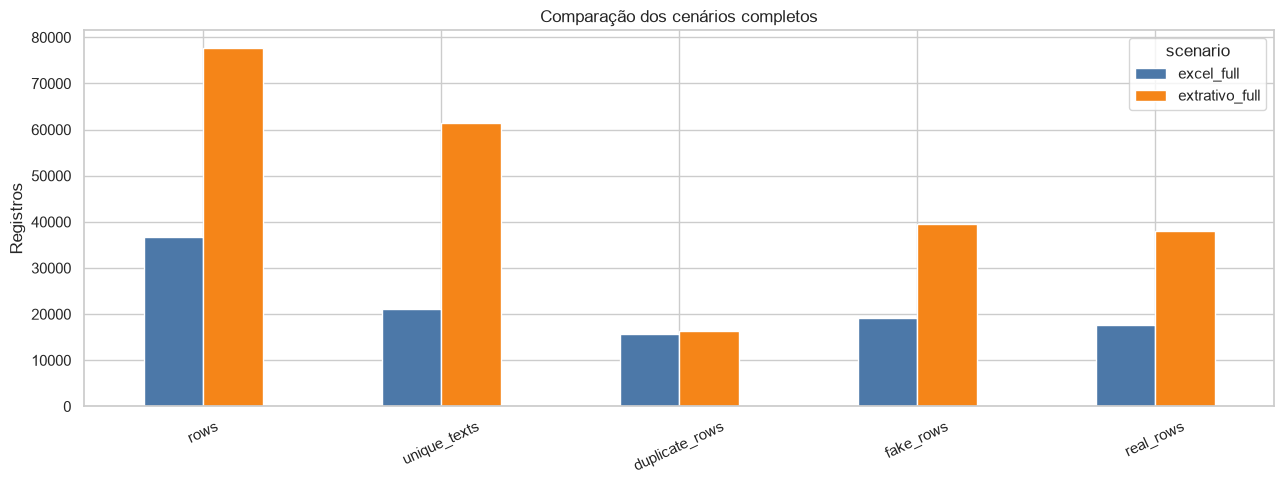

In [8]:
plot_metrics = comparison_full[['rows', 'unique_texts', 'duplicate_rows', 'fake_rows', 'real_rows']]
ax = plot_metrics.T.plot.bar(figsize=(13, 5), color=['#4c78a8', '#f58518'])
ax.set_title('Comparação dos cenários completos')
ax.set_ylabel('Registros')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

In [9]:
scenario_token_summary = []
for scenario, recogna_key in [('excel_full', 'recogna_excel'), ('extrativo_full', 'recogna_extrativo')]:
    combined = np.concatenate([token_lengths[recogna_key], token_lengths['fake_true_br'], token_lengths['whatsapp']])
    scenario_token_summary.append({
        'scenario': scenario,
        'mediana_tokens': float(np.median(combined)),
        'percentual_acima_512': float((combined > 512).mean() * 100),
    })
scenario_token_summary = pd.DataFrame(scenario_token_summary).set_index('scenario')
display(scenario_token_summary)

,mediana_tokens,percentual_acima_512
scenario,,
excel_full,105.0,8.244225
extrativo_full,128.0,4.190074


## 4. Sobreposição entre fontes e risco de leakage

As matrizes abaixo contam textos normalizados exatamente compartilhados. As taxas de assinatura medem termos de veículos e checagem no próprio texto, que podem funcionar como atalhos durante o treinamento.

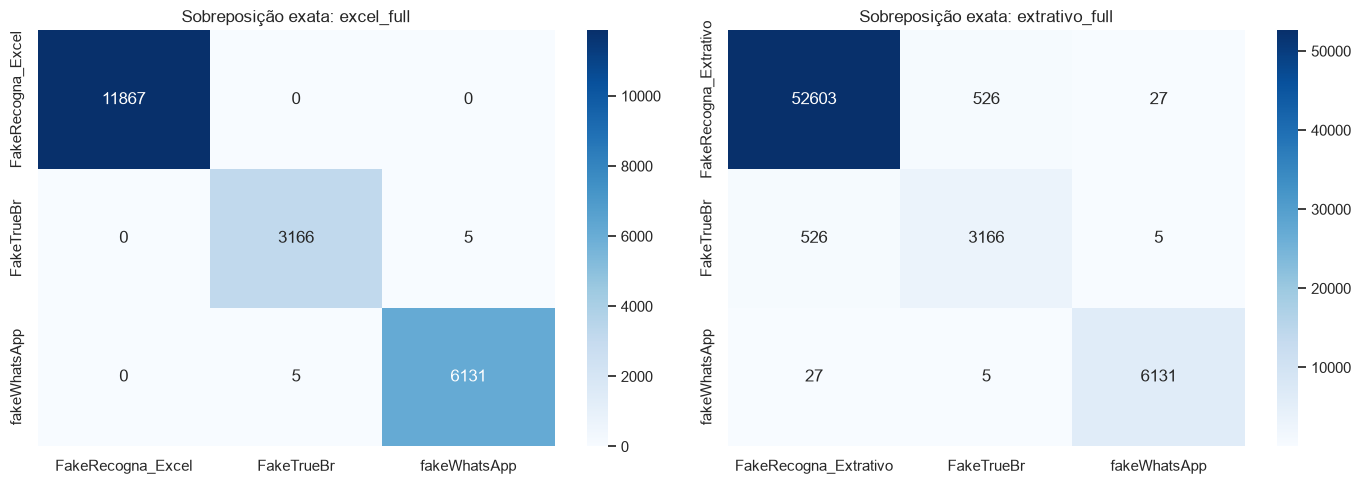

,assinaturas_checagem_pct,urls_no_texto_pct,label_conflicts
scenario,,,
excel_full,9.966533,16.289827,1
extrativo_full,8.993455,7.810648,7


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, scenario in zip(axes, ['excel_full', 'extrativo_full']):
    overlap = source_overlap(scenarios[scenario])
    sns.heatmap(overlap, annot=True, fmt='g', cmap='Blues', ax=axis)
    axis.set_title(f'Sobreposição exata: {scenario}')
plt.tight_layout()
plt.show()

leakage = comparison_full[['check_signature_rate', 'url_rate', 'label_conflicts']].copy()
leakage[['check_signature_rate', 'url_rate']] *= 100
leakage = leakage.rename(columns={
    'check_signature_rate': 'assinaturas_checagem_pct',
    'url_rate': 'urls_no_texto_pct',
})
display(leakage)

## 5. Termos discriminantes e leitura final

Os termos abaixo ajudam a identificar possíveis diferenças temáticas ou editoriais entre falso e verdadeiro. Eles são diagnóstico de viés potencial, não explicação causal.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

def discriminative_terms(frame, top_n=20):
    vectorizer = TfidfVectorizer(lowercase=True, min_df=5, max_df=.95, ngram_range=(1, 2), max_features=30000)
    matrix = vectorizer.fit_transform(frame['text'])
    names = np.asarray(vectorizer.get_feature_names_out())
    scores, _ = chi2(matrix, frame['label'])
    fake_mask = frame['label'].eq(0).to_numpy()
    real_mask = frame['label'].eq(1).to_numpy()
    mean_fake = np.asarray(matrix[fake_mask].mean(axis=0)).ravel()
    mean_real = np.asarray(matrix[real_mask].mean(axis=0)).ravel()
    fake_candidates = np.where(mean_fake > mean_real, scores, -np.inf)
    real_candidates = np.where(mean_real > mean_fake, scores, -np.inf)
    result = {
        'Falso': names[np.argsort(fake_candidates)[-top_n:][::-1]],
        'Verdadeiro': names[np.argsort(real_candidates)[-top_n:][::-1]],
    }
    return pd.DataFrame(result)

display(discriminative_terms(scenarios['extrativo_full']))

,Falso,Verdadeiro
0,circula,saúde
1,no facebook,feira
2,vídeo,coronavírus
3,lula,nesta
4,redes,pandemia
5,redes sociais,casos
6,publicações,covid 19
7,facebook,covid
8,sociais,19
9,nas redes,da saúde


In [12]:
final_table = comparison_full.join(scenario_token_summary)
final_table['retencao_apos_deduplicacao_pct'] = [
    len(scenarios['excel_deduplicated']) / len(scenarios['excel_full']) * 100,
    len(scenarios['extrativo_deduplicated']) / len(scenarios['extrativo_full']) * 100,
]
display(final_table.T)

print('A decisão de corpus deve considerar ganho de diversidade, conflitos de rótulo, leakage e custo de truncamento; volume isolado não define qualidade.')

scenario,excel_full,extrativo_full
rows,36753.000000,77612.000000
fake_rows,19137.000000,39573.000000
real_rows,17616.000000,38039.000000
fake_rate,0.520692,0.509882
unique_texts,21159.000000,61347.000000
duplicate_rows,15594.000000,16265.000000
label_conflicts,1.000000,7.000000
median_chars,416.000000,510.000000
median_words,62.000000,83.000000
check_signature_rate,0.099665,0.089935


A decisão de corpus deve considerar ganho de diversidade, conflitos de rótulo, leakage e custo de truncamento; volume isolado não define qualidade.
